d:\conda_envs\deepLearning\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2025-12-19 18:45:03,063] A new study created in memory with name: no-name-d91f938f-b5ca-41ce-b56c-102b9dc4d940


成功读取文件！数据前5行：
   feature1  feature2  label
0 -0.606902  0.777869    0.0
1 -0.314722  0.246056    1.0
2  0.196496 -0.294496    1.0
3  0.020158  0.982764    0.0
4 -0.793425 -0.686928    0.0

开始 Optuna 调参...


[I 2025-12-19 18:45:08,815] Trial 0 finished with value: 1.0 and parameters: {'affinity': 'nearest_neighbors', 'n_neighbors': 19}. Best is trial 0 with value: 1.0.
[I 2025-12-19 18:45:08,868] Trial 1 finished with value: 1.0 and parameters: {'affinity': 'nearest_neighbors', 'n_neighbors': 15}. Best is trial 0 with value: 1.0.
[I 2025-12-19 18:45:09,040] Trial 2 finished with value: 0.16993563867811792 and parameters: {'affinity': 'rbf', 'gamma': 3.472525759629596}. Best is trial 0 with value: 1.0.
d:\conda_envs\deepLearning\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
[I 2025-12-19 18:45:09,107] Trial 3 finished with value: 1.0 and parameters: {'affinity': 'nearest_neighbors', 'n_neighbors': 11}. Best is trial 0 with value: 1.0.
d:\conda_envs\deepLearning\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spect


----------------------------------
最佳参数: {'affinity': 'nearest_neighbors', 'n_neighbors': 19}
最佳 ARI 分数: 1.0
----------------------------------


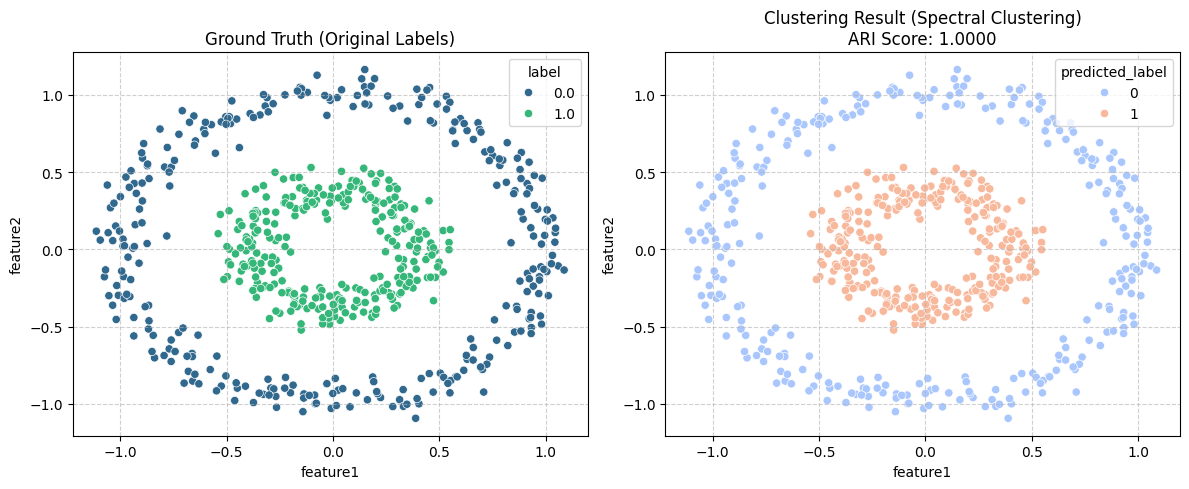


前20个数据的预测标签列表:
[0 1 1 0 0 0 0 1 0 1 0 0 0 1 1 0 0 0 0 0]


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from sklearn.datasets import make_circles
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import SpectralClustering
from sklearn.metrics import adjusted_rand_score
from sklearn.pipeline import Pipeline


# ==========================================
# 1. 数据准备 (读取真实的 CSV 文件)
# ==========================================

# 假设你的文件名为 'circle_data.csv'，请修改为你实际的文件路径
# 确保文件和脚本在同一目录下，或者填写绝对路径
csv_file_path = 'D:\\python_demo\\coding\\data\\circles.csv' 

try:
    # 读取文件
    df = pd.read_csv(csv_file_path)
    
    print("成功读取文件！数据前5行：")
    print(df.head())
    
    # -----------------------------------------------------------
    # 关键步骤：分离特征 (Features) 和 标签 (Labels)
    # -----------------------------------------------------------
    # 聚类是无监督学习，训练时只能用特征 (feature1, feature2)
    # label 列只用于最后的评估 (调参时计算分数)
    
    # 提取特征数据 (去掉 label 列)
    X = df[['feature1', 'feature2']].values
    
    # 提取真实标签 (仅用于 Optuna 评估分数，训练时不传给模型)
    y_true = df['label'].values

except FileNotFoundError:
    print(f"错误：找不到文件 {csv_file_path}，请检查文件名或路径。")
    # 为了防止代码报错停止，这里生成模拟数据作为备选方案
    from sklearn.datasets import make_circles
    print("正在使用模拟数据代替...")
    X, y_true = make_circles(n_samples=500, factor=0.5, noise=0.05, random_state=42)
    df = pd.DataFrame(X, columns=['feature1', 'feature2'])
    df['label'] = y_true

# ==========================================
# 2. 定义 Optuna 目标函数
# ==========================================
def objective(trial):
    # 提取特征
    data = df[['feature1', 'feature2']].values
    labels_true = df['label'].values
    
    # --- 定义搜索空间 ---
    # 谱聚类的 affinity (亲和度) 计算方式
    affinity_type = trial.suggest_categorical('affinity', ['rbf', 'nearest_neighbors'])
    
    # 根据 affinity 类型动态调整参数
    params = {
        'n_clusters': 2, # 已知是两个圆，固定为2（也可以让Optuna去猜，但在Circle数据中通常已知）
        'affinity': affinity_type,
        'random_state': 42
    }
    
    if affinity_type == 'rbf':
        # rbf 核需要调整 gamma
        params['gamma'] = trial.suggest_float('gamma', 0.1, 10.0, log=True)
    else:
        # nearest_neighbors 需要调整邻居数量
        params['n_neighbors'] = trial.suggest_int('n_neighbors', 5, 20)

    # --- 管道化思想 (标准化 -> 聚类) ---
    # 注意：sklearn的Pipeline通常用于Transform+Predict。
    # 对于聚类，我们通常手动按顺序执行，或者自定义Wrapper。
    # 这里为了体现Pipeline思想，我们分步执行，逻辑上保持流式处理。
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(data)
    
    model = SpectralClustering(**params)
    
    # 聚类并获取标签
    labels_pred = model.fit_predict(X_scaled)
    
    # --- 评估指标 ---
    # 使用调整兰德系数 (ARI) 对比预测结果和真实标签
    # ARI 范围 [-1, 1]，越接近 1 效果越好
    score = adjusted_rand_score(labels_true, labels_pred)
    
    return score

# ==========================================
# 3. 运行 Optuna 优化
# ==========================================
print("\n开始 Optuna 调参...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20) # 尝试20次实验

print("\n----------------------------------")
print("最佳参数:", study.best_params)
print("最佳 ARI 分数:", study.best_value)
print("----------------------------------")

# ==========================================
# 4. 使用最佳参数进行最终训练与可视化
# ==========================================
best_params = study.best_params
affinity = best_params.pop('affinity')

# 构建最终模型参数
final_params = {
    'n_clusters': 2,
    'affinity': affinity,
    'random_state': 42
}
if affinity == 'rbf':
    final_params['gamma'] = best_params['gamma']
else:
    final_params['n_neighbors'] = best_params['n_neighbors']

# 标准化数据
scaler = StandardScaler()
X_final = scaler.fit_transform(df[['feature1', 'feature2']].values)

# 训练模型
model = SpectralClustering(**final_params)
predicted_labels = model.fit_predict(X_final)

# 将结果放回 DataFrame
df['predicted_label'] = predicted_labels

# ==========================================
# 5. 可视化展示
# ==========================================
plt.figure(figsize=(12, 5))

# 图1: 原始真实分类
plt.subplot(1, 2, 1)
sns.scatterplot(x='feature1', y='feature2', hue='label', data=df, palette='viridis')
plt.title('Ground Truth (Original Labels)')
plt.grid(True, linestyle='--', alpha=0.6)

# 图2: 聚类预测结果
plt.subplot(1, 2, 2)
sns.scatterplot(x='feature1', y='feature2', hue='predicted_label', data=df, palette='coolwarm')
plt.title(f'Clustering Result (Spectral Clustering)\nARI Score: {study.best_value:.4f}')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 返回要求的标签列表
print("\n前20个数据的预测标签列表:")
print(predicted_labels[:20])